The Normal Equation

In [1]:
#Test the Normal Equation
import numpy as np

In [2]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [3]:
import matplotlib.pyplot as plt

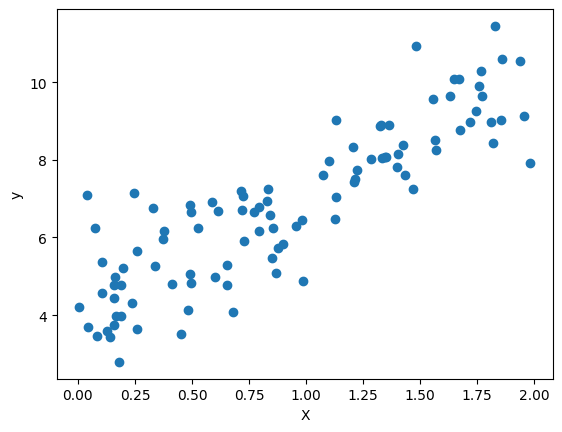

In [4]:
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [5]:
X_b = np.c_[np.ones((100, 1)), X]
X_b

array([[1.        , 1.76500234],
       [1.        , 1.33089215],
       [1.        , 0.04009536],
       [1.        , 0.25806735],
       [1.        , 0.72295559],
       [1.        , 1.81787933],
       [1.        , 0.65366863],
       [1.        , 1.56815536],
       [1.        , 0.71493083],
       [1.        , 1.35074264],
       [1.        , 0.19542771],
       [1.        , 0.07450691],
       [1.        , 1.71622666],
       [1.        , 0.45374318],
       [1.        , 0.04415332],
       [1.        , 0.60075742],
       [1.        , 0.6130466 ],
       [1.        , 0.49084793],
       [1.        , 1.55439633],
       [1.        , 0.72971717],
       [1.        , 0.10400531],
       [1.        , 0.86746454],
       [1.        , 0.16665685],
       [1.        , 0.85653049],
       [1.        , 0.8279234 ],
       [1.        , 1.93822507],
       [1.        , 1.76984633],
       [1.        , 0.79418993],
       [1.        , 0.49689791],
       [1.        , 1.85951675],
       [1.

In [6]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.0831064 ],
       [2.99781573]])

In [7]:
X_new = np.array([[0], [2]])
X_new

array([[0],
       [2]])

In [8]:
X_new_b = np.c_[np.ones((2, 1)), X_new]
X_new_b

array([[1., 0.],
       [1., 2.]])

In [9]:
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 4.0831064 ],
       [10.07873786]])

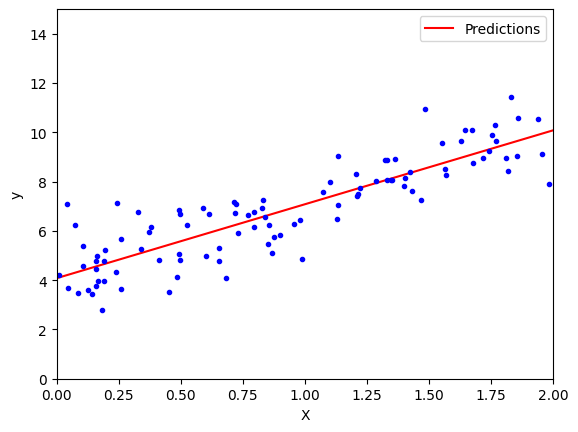

In [10]:
plt.plot(X_new, y_predict, 'r-', label='Predictions')
plt.plot(X, y, 'b.')
plt.axis([0, 2, 0, 15])
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [11]:
# Perform Linear Regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [12]:
lin_reg.fit(X,y)

LinearRegression()

In [13]:
lin_reg.intercept_, lin_reg.coef_

(array([4.0831064]), array([[2.99781573]]))

In [14]:
lin_reg.predict(X_new)

array([[ 4.0831064 ],
       [10.07873786]])

In [15]:
# Compare with the function Linear Regression is based on
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond = 1e-6)
theta_best_svd

array([[4.0831064 ],
       [2.99781573]])

In [16]:
# Compute the pseudoinverse directly
np.linalg.pinv(X_b).dot(y)

array([[4.0831064 ],
       [2.99781573]])

In [17]:
# Compute the Batch Gradient Descent
eta = 0.1 #learning rate
n_iterations = 1000
m = 100

In [18]:
theta = np.random.randn(2,1) #random initialization

In [19]:
for iteration in range (n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [20]:
theta

array([[4.0831064 ],
       [2.99781573]])

In [21]:
#Compute Stochastic Gradient Descent

n_epochs = 50 #rounds of iteration
t0, t1 = 5, 50 # learning schedule hyperparameters

In [22]:
def learning_schedule (t):
    return t0/(t + t1)

In [23]:
import numpy as np
theta = np.random.randn(2,1) #random initialization

In [24]:
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + 1)
        theta = theta - eta * gradients

In [25]:
theta

array([[4.06878604],
       [2.98503889]])

In [26]:
#Linear Regression using Stochastic GD
from sklearn.linear_model import SGDRegressor

In [27]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [28]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.02708265]), array([2.94151482]))

Polynomial Regression

In [29]:
#Generate nonlinear data
import numpy as np

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

In [81]:
X_rav = X.ravel()

Text(0, 0.5, 'y')

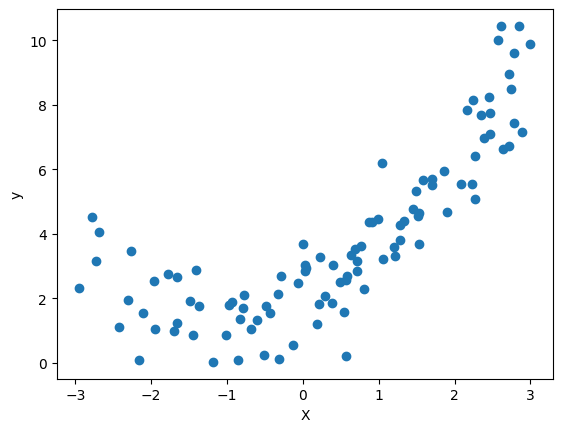

In [30]:
import matplotlib.pyplot as plt

plt.scatter (X, y)
plt.xlabel('X')
plt.ylabel('y')

In [31]:
#Transfor training data by adding the square of each feature (second-degree)
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [32]:
X[0]

array([-0.31312357])

In [33]:
X_poly[0]

array([-0.31312357,  0.09804637])

In [34]:
# Fit LinearRegression model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [35]:
lin_reg.fit(X_poly, y)

LinearRegression()

In [36]:
lin_reg.intercept_, lin_reg.coef_

(array([2.00506518]), array([[1.04560419, 0.49614923]]))

That means the model is y = 0.44x^2 + 0.90x + 2.25

The original function was y = 0.5x^2 + x + 2 + gaussian noise

In [37]:
new_X = np.linspace(-3, 3, 100).reshape(100, 1)
new_X_poly = poly_features.fit_transform(new_X)

In [38]:
y_predict = lin_reg.predict(new_X_poly)

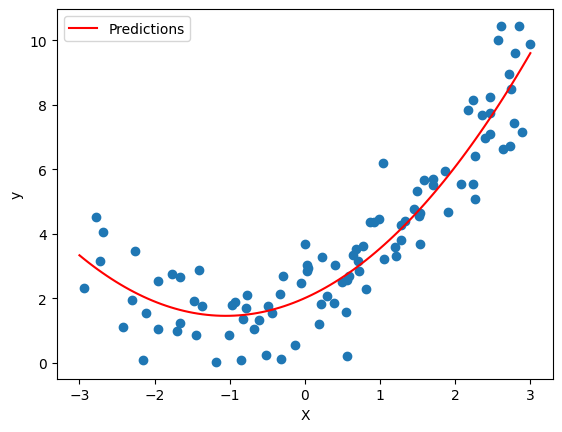

In [39]:
plt.scatter (X, y)
plt.plot(new_X, y_predict, '-', color='red', label='Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

Learning Curves

In [40]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [41]:
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errrors, val_errors = [], []

    for m in range (1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errrors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    
    plt.plot(np.sqrt(train_errrors), 'r-+', linewidth=2, label='train')
    plt.plot(np.sqrt(val_errors), 'b-', linewidth=3, label='val')
    plt.xlabel('Training set size')
    plt.ylabel('RMSE')
    plt.legend()

In [42]:
# Fit LinearRegression model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [43]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

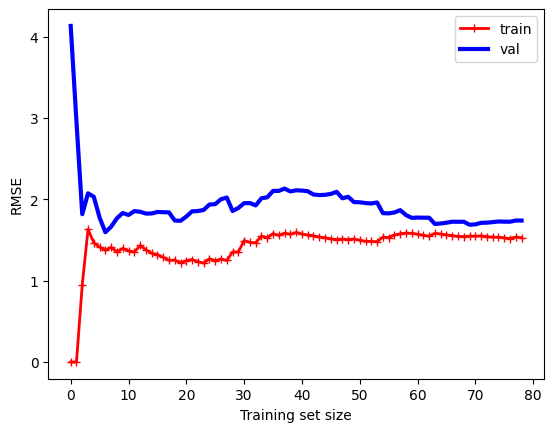

In [44]:
plot_learning_curves(lin_reg, X, y)

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [46]:
polynomial_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree=10, include_bias=False)),
    ('lin_reg', LinearRegression())
])

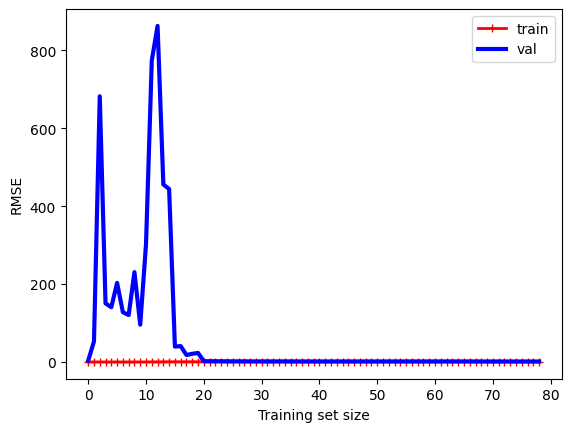

In [47]:
plot_learning_curves(polynomial_regression, X, y)

Regularized Linear Models

Ridge Regression

In [48]:
#Generate nonlinear data
import numpy as np

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

In [49]:
from sklearn.linear_model import Ridge

In [50]:
ridge_reg = Ridge(alpha=1, solver='cholesky')

In [51]:
ridge_reg.fit(X, y)

Ridge(alpha=1, solver='cholesky')

In [52]:
ridge_reg.predict([[1.5]])

array([4.98649485])

In [53]:
from sklearn.linear_model import SGDRegressor

In [54]:
sgd_reg = SGDRegressor(penalty='l2')

In [55]:
sgd_reg.fit(X, y.ravel())

SGDRegressor()

In [56]:
sgd_reg.predict([[1.5]])

array([4.96282439])

Lasso Regression

In [57]:
from sklearn.linear_model import Lasso

In [58]:
lasso_reg = Lasso(alpha=0.1)

In [59]:
lasso_reg.fit(X, y)

Lasso(alpha=0.1)

In [60]:
lasso_reg.predict([[1.5]])

array([4.94546652])

In [61]:
from sklearn.linear_model import SGDRegressor

In [62]:
sgd_reg = SGDRegressor(penalty='l1')

In [63]:
sgd_reg.fit(X, y.ravel())

SGDRegressor(penalty='l1')

In [64]:
sgd_reg.predict([[1.5]])

array([4.98463673])

Elastic Net

In [65]:
from sklearn.linear_model import ElasticNet

In [66]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [67]:
elastic_net.fit(X, y)

ElasticNet(alpha=0.1)

In [68]:
elastic_net.predict([[1.5]])

array([4.94582938])